# CAMELS three-dimensional fields: from volume visualization to Lyα forest synthesis

This notebook develops a continuous analysis of the downloaded CAMELS Multifield Dataset (CMD) grids. Part I establishes how the three-dimensional arrays are stored and visualizes representative slices from multiple simulations. Part II then constructs a one-dimensional sightline (or skewer), introduces the Voigt profile, extracts the physical fields required for Lyα absorption, and synthesizes a transmitted-flux spectrum.


# Part I — Inspecting and visualizing the CAMELS volumes

We begin by opening the downloaded three-dimensional CAMELS Multifield Dataset grids and examining thin planar sections through them. The files considered here belong to the **IllustrisTNG CV set at redshift $z=2$**. In the CV (cosmic-variance) set, the cosmological and astrophysical parameters are fixed, while the 27 simulations differ in their random initial conditions. Throughout this notebook, the leading array index is therefore referred to as the simulation or seed number.

The discussion follows the [CAMELS Multifield Dataset description](https://camels-multifield-dataset.readthedocs.io/en/latest/data.html).

## 1.1 Import the basic numerical and plotting tools

In [220]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


In [221]:
# A small, dependency-free plotting style used throughout the notebook.
# Change these values once if you need larger text for a projector.
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 180,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.8,
        "legend.frameon": False,
        "xtick.direction": "out",
        "ytick.direction": "out",
    }
)

COLORS = {
    "density": "#2667A8",
    "temperature": "#D97706",
    "optical_depth": "#C9343A",
    "flux": "#16803A",
    "highlight": "#D81B60",
    "reference": "#6B7280",
}


def safe_log10(values):
    '''Return log10(values), representing non-positive entries as NaN.'''
    values = np.asarray(values)
    return np.where(values > 0, np.log10(values), np.nan)


def robust_limits(images, lower_percentile=1.0, upper_percentile=99.5):
    '''Shared colour limits that are not controlled by a few outliers.'''
    finite_values = np.concatenate(
        [image[np.isfinite(image)].ravel() for image in images]
    )
    return np.percentile(
        finite_values,
        [lower_percentile, upper_percentile],
    )


def finish_axis(ax, grid_axis="both"):
    '''Apply the same light visual treatment to a line-plot axis.'''
    ax.grid(axis=grid_axis, color="0.88", linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)


## 1.2 Identify the downloaded files

Each component of a filename records a property of the stored data. For example,

**Grids_Mcdm_IllustrisTNG_CV_128_z=2.0.npy**

denotes a three-dimensional **grid** of the cold-dark-matter field (**Mcdm**), generated from the **IllustrisTNG** simulation suite and belonging to the **CV** set. Each spatial axis contains 128 voxels, and the snapshot redshift is $z=2$. The .npy suffix identifies NumPy's native array format.

In [222]:
data_directory = Path("Sims/CMD_z=2_grid128")

if not data_directory.exists():
    raise FileNotFoundError(
        f"Could not find {data_directory.resolve()}. "
        "Create this directory and place the downloaded CAMELS .npy files inside it."
    )

files = sorted(data_directory.glob("*.npy"))
if not files:
    raise FileNotFoundError(f"No .npy files were found in {data_directory.resolve()}.")

print(f"Found {len(files)} CAMELS grid files:\n")
for file_path in files:
    print(f"  • {file_path.name}")


Found 5 CAMELS grid files:

  • Grids_HI_IllustrisTNG_CV_128_z=2.0.npy
  • Grids_Mcdm_IllustrisTNG_CV_128_z=2.0.npy
  • Grids_Mgas_IllustrisTNG_CV_128_z=2.0.npy
  • Grids_T_IllustrisTNG_CV_128_z=2.0.npy
  • Grids_Vgas_IllustrisTNG_CV_128_z=2.0.npy


The five available field prefixes and their units are:

| Prefix | Physical quantity | Unit in a three-dimensional grid |
|---|---|---|
| Mcdm | cold-dark-matter density | $(M_\odot/h)/(\mathrm{Mpc}/h)^3$ |
| Mgas | gas density | $(M_\odot/h)/(\mathrm{Mpc}/h)^3$ |
| HI | neutral-hydrogen density | $(M_\odot/h)/(\mathrm{Mpc}/h)^3$ |
| T | gas temperature | K |
| Vgas | gas velocity modulus | km/s |

Fields carrying the same simulation index describe the same simulated volume and may therefore be compared voxel by voxel.

## 1.3 Examine how a file is stored

A file contains **27 distinct three-dimensional volumes**, rather than a single volume. NumPy reports the shape as

$$(\mathrm{simulation\ index},x,y,z)=(27,128,128,128).$$

Every periodic simulation box spans $(25\,h^{-1}\mathrm{Mpc})^3$, so the voxel width is

$$\Delta x=\frac{25}{128}\simeq0.195\,h^{-1}\mathrm{Mpc}.$$

Along the line of sight, this spatial scale can also be expressed as a Hubble velocity interval. At redshift $z$,

$$
\Delta v=\frac{H(z)}{1+z}\,\Delta x,
$$

where $\Delta x$ is the comoving voxel width. For $\Delta x=0.195\,h^{-1}\mathrm{Mpc}$ at $z=2$,

$$
\Delta v \simeq 20\,\mathrm{km\,s^{-1}}.
$$

Thus, each CAMELS voxel corresponds to roughly $20\,\mathrm{km\,s^{-1}}$ along the line of sight at $z=2$.

In [223]:
file_path = data_directory / "Grids_Mcdm_IllustrisTNG_CV_128_z=2.0.npy"

# Memory mapping reads only the slices requested below instead of copying
# every simulation volume into RAM at once.
grids = np.load(file_path, mmap_mode="r")

print(f"Array shape              : {grids.shape}")
print(f"Stored data type          : {grids.dtype}")
print(f"Complete file size in RAM : {grids.nbytes / 1024**2:.1f} MiB")
print(f"One 3D volume size in RAM : {grids[0].nbytes / 1024**2:.1f} MiB")


Array shape              : (27, 128, 128, 128)
Stored data type          : float32
Complete file size in RAM : 216.0 MiB
One 3D volume size in RAM : 8.0 MiB


## 1.4 Extract and display one central slice

We first select a simulation and a position along the third spatial axis. Direct NumPy indexing leaves a $128\times128$ array suitable for display. This operation extracts a one-voxel-thick **slice**; it is not a projection or a sum through the complete volume.

Cosmological densities span several orders of magnitude. We therefore display $\log_{10}$ of the density to make both underdense and overdense structures visible. The transpose operation (.T) affects only the orientation of the displayed image: it places the first spatial array axis on the horizontal plotting axis.

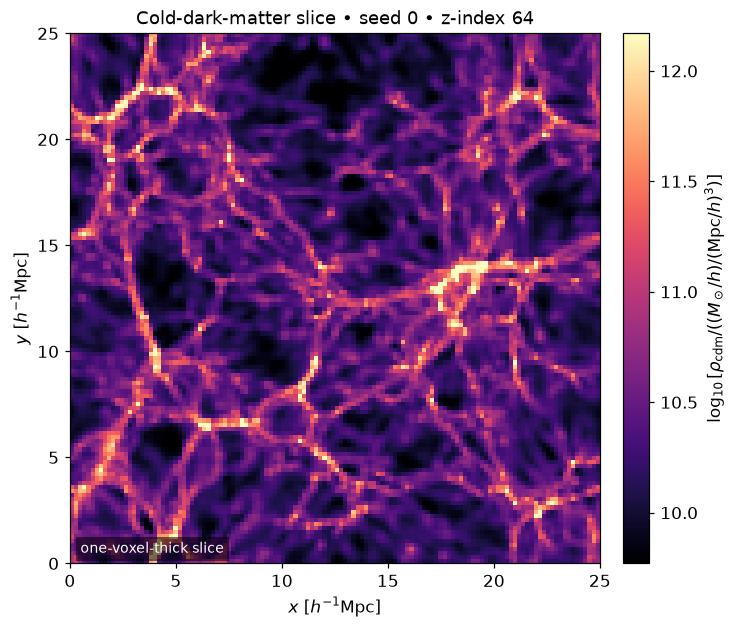

In [224]:
seed = 0
slice_number = 64

density_slice = grids[seed, :, :, slice_number]
log_density_slice = safe_log10(density_slice).T
colour_min, colour_max = robust_limits([log_density_slice])

fig, ax = plt.subplots(figsize=(6.8, 5.6), constrained_layout=True)
image = ax.imshow(
    log_density_slice,
    origin="lower",
    extent=[0, 25, 0, 25],
    cmap="magma",
    vmin=colour_min,
    vmax=colour_max,
    interpolation="nearest",
)
colourbar = fig.colorbar(image, ax=ax, pad=0.02)
colourbar.set_label(
    r"$\log_{10}[\rho_{\rm cdm}/((M_\odot/h)/(\mathrm{Mpc}/h)^3)]$"
)

ax.set(
    xlabel=r"$x\ [h^{-1}\mathrm{Mpc}]$",
    ylabel=r"$y\ [h^{-1}\mathrm{Mpc}]$",
    title=f"Cold-dark-matter slice • seed {seed} • z-index {slice_number}",
    aspect="equal",
)
ax.text(
    0.02,
    0.02,
    "one-voxel-thick slice",
    transform=ax.transAxes,
    color="white",
    fontsize=9,
    bbox={"facecolor": "black", "alpha": 0.55, "edgecolor": "none", "pad": 3},
)
plt.show()


## 1.5 Compare all five fields for two seeds

We now repeat the same indexing operation for seeds 0 and 1 and for every downloaded field. **Columns correspond to independent random initial conditions; rows correspond to physical fields.** Within a row, both seeds use the same colour limits, so their structures can be compared fairly.

The colour limits are the 1st and 99.5th percentiles of the two displayed slices. This robust scaling reveals diffuse structure without allowing a handful of extreme pixels to determine the entire colour map. The numerical data are unchanged.


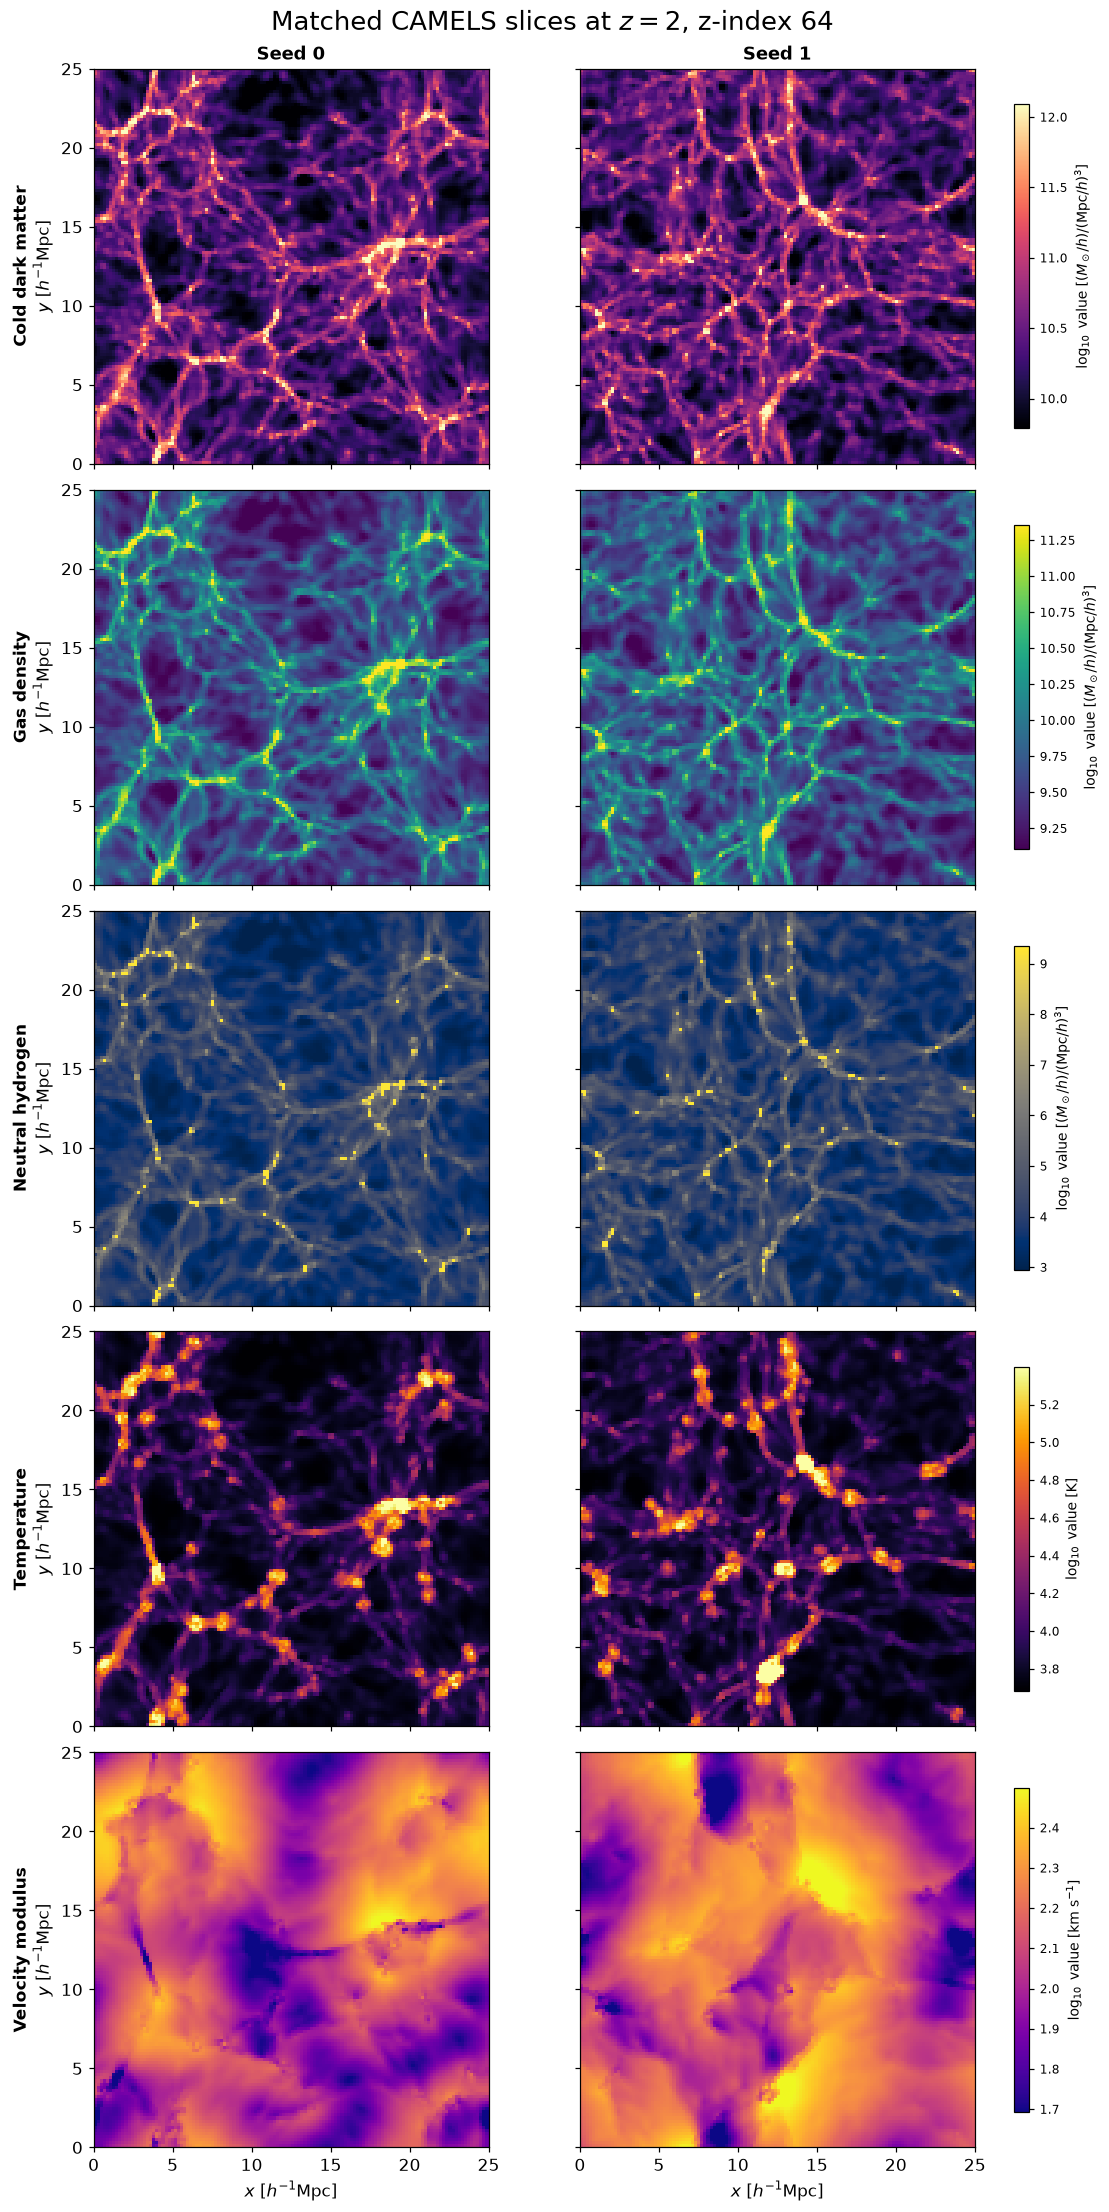

In [225]:
fields = {
    "Mcdm": {
        "name": "Cold dark matter",
        "unit": r"$(M_\odot/h)/(\mathrm{Mpc}/h)^3$",
        "cmap": "magma",
    },
    "Mgas": {
        "name": "Gas density",
        "unit": r"$(M_\odot/h)/(\mathrm{Mpc}/h)^3$",
        "cmap": "viridis",
    },
    "HI": {
        "name": "Neutral hydrogen",
        "unit": r"$(M_\odot/h)/(\mathrm{Mpc}/h)^3$",
        "cmap": "cividis",
    },
    "T": {
        "name": "Temperature",
        "unit": "K",
        "cmap": "inferno",
    },
    "Vgas": {
        "name": "Velocity modulus",
        "unit": "km s$^{-1}$",
        "cmap": "plasma",
    },
}

seeds = [0, 1]
slice_number = 64

fig, axes = plt.subplots(
    nrows=len(fields),
    ncols=len(seeds),
    figsize=(10, 20),
    sharex=True,
    sharey=True,
    layout="constrained",
)

for field_index, (field_prefix, field_info) in enumerate(fields.items()):
    file_path = data_directory / (
        f"Grids_{field_prefix}_IllustrisTNG_CV_128_z=2.0.npy"
    )
    field_boxes = np.load(file_path, mmap_mode="r")

    # Prepare both slices first so they can share one fair colour scale.
    displayed_slices = [
        safe_log10(field_boxes[seed, :, :, slice_number]).T
        for seed in seeds
    ]
    colour_min, colour_max = robust_limits(displayed_slices)

    for seed_index, (seed, displayed_slice) in enumerate(
        zip(seeds, displayed_slices)
    ):
        ax = axes[field_index, seed_index]
        image = ax.imshow(
            displayed_slice,
            origin="lower",
            extent=[0, 25, 0, 25],
            cmap=field_info["cmap"],
            vmin=colour_min,
            vmax=colour_max,
            interpolation="nearest",
        )
        ax.set_aspect("equal")

        if field_index == 0:
            ax.set_title(f"Seed {seed}", fontweight="semibold")
        if seed_index == 0:
            ax.set_ylabel(
                field_info["name"] + "\n" + r"$y\ [h^{-1}\mathrm{Mpc}]$",
                fontweight="semibold",
            )
        if field_index == len(fields) - 1:
            ax.set_xlabel(r"$x\ [h^{-1}\mathrm{Mpc}]$")

    colourbar = fig.colorbar(
        image,
        ax=axes[field_index, :],
        orientation="vertical",
        shrink=0.82,
        pad=0.03,
        aspect=22,
    )
    colourbar.set_label(
        rf"$\log_{{10}}$ value [{field_info['unit']}]",
        fontsize=9,
    )
    colourbar.ax.tick_params(labelsize=8)

fig.suptitle(
    rf"Matched CAMELS slices at $z=2$, z-index {slice_number}",
    fontsize=17,
)
plt.show()


## 1.6 Connect the maps with a temperature–density phase diagram

Maps show **where** structures are; a phase diagram shows **which physical states** the gas occupies. Define the gas overdensity as

$$\Delta_{\rm gas}=\frac{\rho_{\rm gas}}{\langle\rho_{\rm gas}\rangle}.$$

The two-dimensional density map below uses many voxels without plotting millions of overlapping markers. The solid curve is the median temperature in bins of $\log_{10}\Delta_{\rm gas}$. We fit those binned medians over $-1 \leq \log_{10}\Delta_{\rm gas} \leq 0.2$ with the standard power-law temperature–density relation

$$T=T_0\Delta_{\rm gas}^{\gamma-1},$$

or equivalently $\log_{10}T=\log_{10}T_0+(\gamma-1)\log_{10}\Delta_{\rm gas}$. This view prepares us for the next part: Lyα absorption depends jointly on neutral-hydrogen density and temperature.


Median-relation fit over -1.0 <= log10(Delta) <= 0.2: T0 = 1.135e+04 K, gamma = 1.402


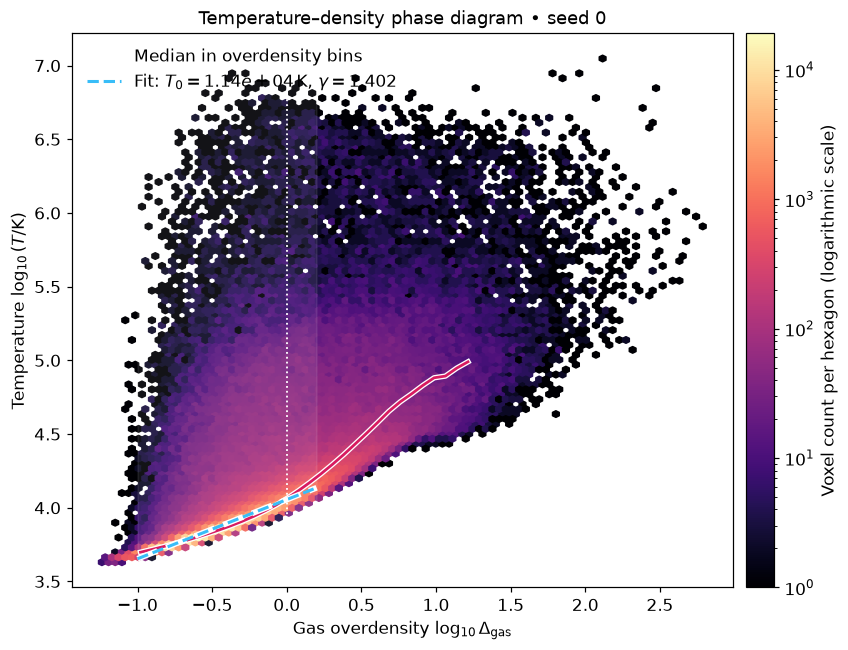

In [226]:
phase_seed = 0
gas_boxes = np.load(
    data_directory / "Grids_Mgas_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)
temperature_boxes = np.load(
    data_directory / "Grids_T_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)

gas_density = np.asarray(gas_boxes[phase_seed])
gas_temperature = np.asarray(temperature_boxes[phase_seed])
gas_overdensity = gas_density / gas_density.mean()

valid = (
    np.isfinite(gas_overdensity)
    & np.isfinite(gas_temperature)
    & (gas_overdensity > 0)
    & (gas_temperature > 0)
)
log_overdensity = np.log10(gas_overdensity[valid])
log_temperature = np.log10(gas_temperature[valid])

# Compute a median relation using all valid voxels.
bin_edges = np.linspace(
    np.percentile(log_overdensity, 0.5),
    np.percentile(log_overdensity, 99.5),
    31,
)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
median_log_temperature = np.full(bin_centres.shape, np.nan)

for bin_index in range(len(bin_centres)):
    in_bin = (
        (log_overdensity >= bin_edges[bin_index])
        & (log_overdensity < bin_edges[bin_index + 1])
    )
    if np.any(in_bin):
        median_log_temperature[bin_index] = np.median(
            log_temperature[in_bin]
        )

# Fit the binned median relation in the low-density IGM.
fit_log_delta_min = -1.0
fit_log_delta_max = 0.2
fit_bins = (
    np.isfinite(median_log_temperature)
    & (bin_centres >= fit_log_delta_min)
    & (bin_centres <= fit_log_delta_max)
)
gamma_minus_one, log10_T0 = np.polyfit(
    bin_centres[fit_bins],
    median_log_temperature[fit_bins],
    deg=1,
)
gamma = gamma_minus_one + 1.0
T0 = 10.0**log10_T0
fit_log_delta = np.linspace(fit_log_delta_min, fit_log_delta_max, 200)
fit_log_temperature = log10_T0 + gamma_minus_one * fit_log_delta

print(
    f"Median-relation fit over {fit_log_delta_min:.1f} <= log10(Delta) "
    f"<= {fit_log_delta_max:.1f}: T0 = {T0:.3e} K, gamma = {gamma:.3f}"
)

# Plot every fourth valid voxel: this is only a display subsample.
display_step = 4
fig, ax = plt.subplots(figsize=(7.6, 5.8), constrained_layout=True)
density_plot = ax.hexbin(
    log_overdensity[::display_step],
    log_temperature[::display_step],
    gridsize=90,
    bins="log",
    mincnt=1,
    cmap="magma",
)
ax.plot(
    bin_centres,
    median_log_temperature,
    color="white",
    linewidth=3.5,
    label="Median in overdensity bins",
)
ax.plot(
    bin_centres,
    median_log_temperature,
    color=COLORS["highlight"],
    linewidth=1.8,
)
ax.axvspan(
    fit_log_delta_min,
    fit_log_delta_max,
    color="white",
    alpha=0.08,
)
ax.plot(
    fit_log_delta,
    fit_log_temperature,
    color="white",
    linewidth=3.8,
    linestyle="--",
)
ax.plot(
    fit_log_delta,
    fit_log_temperature,
    color="#38BDF8",
    linewidth=2.0,
    linestyle="--",
    label=(
        rf"Fit: $T_0={T0:.2e}\,\mathrm{{K}}$, "
        rf"$\gamma={gamma:.3f}$"
    ),
)
ax.axvline(0.0, color="white", linestyle=":", linewidth=1.2)
ax.set(
    xlabel=r"Gas overdensity $\log_{10}\Delta_{\rm gas}$",
    ylabel=r"Temperature $\log_{10}(T/\mathrm{K})$",
    title=f"Temperature–density phase diagram • seed {phase_seed}",
)
ax.legend(loc="upper left")
colourbar = fig.colorbar(density_plot, ax=ax, pad=0.02)
colourbar.set_label("Voxel count per hexagon (logarithmic scale)")
fig.savefig(
    output_directory / f"CAMELS_temperature_density_seed_{phase_seed}.png",
    bbox_inches="tight",
    facecolor="white",
)
plt.show()


> **Interpretation:** the distribution is broad because several thermal phases coexist at the same density. The median curve summarizes the typical trend, but it should not be mistaken for a deterministic temperature–density law. The CMD temperature is mass-weighted within each voxel.


# Part II — From a three-dimensional volume to a Lyα forest

Having established the geometry, indexing convention, and physical content of the grids, we now reduce the volume to a one-dimensional skewer. The analysis first introduces the atomic line profile and then converts the sampled CAMELS fields into a Lyα optical-depth and transmitted-flux spectrum.

## 2.1 Scientific scope and an important velocity limitation

The CAMELS Multifield Dataset (CMD) grids used here provide:

| File prefix | Stored field | Use in this notebook |
|---|---|---|
| HI | neutral-hydrogen mass density | converted to physical number density, $n_{\rm HI}$ |
| T | mass-weighted gas temperature in K | used for thermal broadening |

Lyα redshift-space absorption requires the **signed component of peculiar velocity parallel to the sightline**, $v_\parallel$. CMD's scalar Vgas grid is non-negative and contains no directional information, so it cannot supply $v_\parallel$. We therefore do not load Vgas and set $v_\parallel=0$ in the optical-depth calculation. The generated spectrum includes Hubble flow and thermal broadening, but not peculiar-velocity distortions.

This is a pedagogical spectrum, not a precision synthetic observation. A complete calculation requires particle data or a vector velocity grid. See the [CMD paper](https://arxiv.org/abs/2109.10915) and [CAMELS data documentation](https://camels-multifield-dataset.readthedocs.io/en/latest/data.html) for the field definitions.

## 2.2 Import the additional scientific dependencies

In [227]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage, special

from astropy import units as u
from astropy.constants import c, m_p, m_e, k_B
from astropy.cosmology import Planck18 as cosmo

## 2.3 The Voigt profile in a continuous field

At every point in the intergalactic medium, Lyα absorption is broadened by both the thermal velocities of hydrogen atoms and the finite lifetime of the excited state. The thermal Doppler parameter is

$$b(s)=\sqrt{\frac{2k_{\rm B}T(s)}{m_{\rm H}}}, \qquad \Delta\nu_{\rm D}(s)=\frac{b(s)}{c}\nu_\alpha,$$

where $s$ labels position along the sightline. The normalized thermal and natural line profiles are respectively

$$\phi_{\rm G}(\nu;s)=\frac{1}{\sqrt{\pi}\,\Delta\nu_{\rm D}(s)}\exp\left[-\left(\frac{\nu}{\Delta\nu_{\rm D}(s)}\right)^2\right],$$

$$\phi_{\rm L}(\nu)=\frac{1}{\pi}\frac{\Gamma_\alpha/(4\pi)}{\nu^2+[\Gamma_\alpha/(4\pi)]^2}.$$

Their convolution gives the local Voigt profile,

$$\phi_{\rm V}(\nu;s)=\int_{-\infty}^{\infty}\phi_{\rm G}(\nu';s)\,\phi_{\rm L}(\nu-\nu')\,d\nu'=\frac{1}{\sqrt{\pi}\,\Delta\nu_{\rm D}(s)}H[a(s),u],$$

with

$$H(a,u)=\frac{a}{\pi}\int_{-\infty}^{\infty}\frac{e^{-y^2}}{(u-y)^2+a^2}\,dy=\operatorname{Re}[w(u+ia)], \qquad u=\frac{\nu}{\Delta\nu_{\rm D}(s)}, \qquad a(s)=\frac{\Gamma_\alpha}{4\pi\Delta\nu_{\rm D}(s)}.$$

For a continuous sightline, the optical depth is the line-of-sight integral of these local profiles, with the appropriate cosmological-redshift and peculiar-velocity shift in the profile argument:

$$\tau(\nu_{\rm obs})=\int n_{\rm HI}(s)\,\sigma_\alpha\,\phi_{\rm V}[\nu_{\rm obs};s]\,ds, \qquad F=\exp(-\tau).$$

This continuous-field expression is what the main CAMELS exercise discretizes over simulation cells. The calculations below instead use isolated clouds with a column density $N_{\rm HI}$,

$$\tau_{\rm cloud}(\Delta v)=N_{\rm HI}\frac{cI_\alpha}{\sqrt{\pi}b}H(a,u).$$

That cloud approximation is included only to demonstrate how $b$ changes the thermal core and how $N_{\rm HI}$ makes damping wings visible. It is not used in the main exercise, which uses the continuous-field form only.

In [228]:
# Lyα atomic constants used in both the cloud demonstration and the
# continuous-field calculation below.
I_alpha = 4.45e-18
lambda_alpha_cm = 1215.67e-8
gamma_alpha = 6.262e8
c_cms = c.to_value(u.cm / u.s)
nu_alpha = c_cms / lambda_alpha_cm


def single_cloud_tau(delta_velocity, column_density_HI, doppler_b):
    '''Return the Lyα optical depth of one idealized absorber.

    Parameters
    ----------
    delta_velocity : array-like
        Velocity offset from line centre in km/s.
    column_density_HI : float
        Neutral-hydrogen column density in cm^-2.
    doppler_b : float
        Thermal Doppler parameter in km/s.
    '''
    doppler_b_cms = doppler_b * 1e5
    damping_parameter = (
        gamma_alpha * c_cms / (4.0 * np.pi * nu_alpha * doppler_b_cms)
    )
    dimensionless_velocity = delta_velocity / doppler_b
    voigt_function = np.real(
        special.wofz(dimensionless_velocity + 1j * damping_parameter)
    )
    cross_section = (
        c_cms
        * I_alpha
        * voigt_function
        / (np.sqrt(np.pi) * doppler_b_cms)
    )
    return column_density_HI * cross_section


### A visual experiment with mock absorbers

The panels below isolate the relevant effects. First we compare the peak-normalized Gaussian, Lorentzian, and Voigt shapes. We then hold $N_{\rm HI}$ fixed while changing $b$, and finally hold $b$ fixed while changing $N_{\rm HI}$. Separating the variables makes their roles easier to identify.

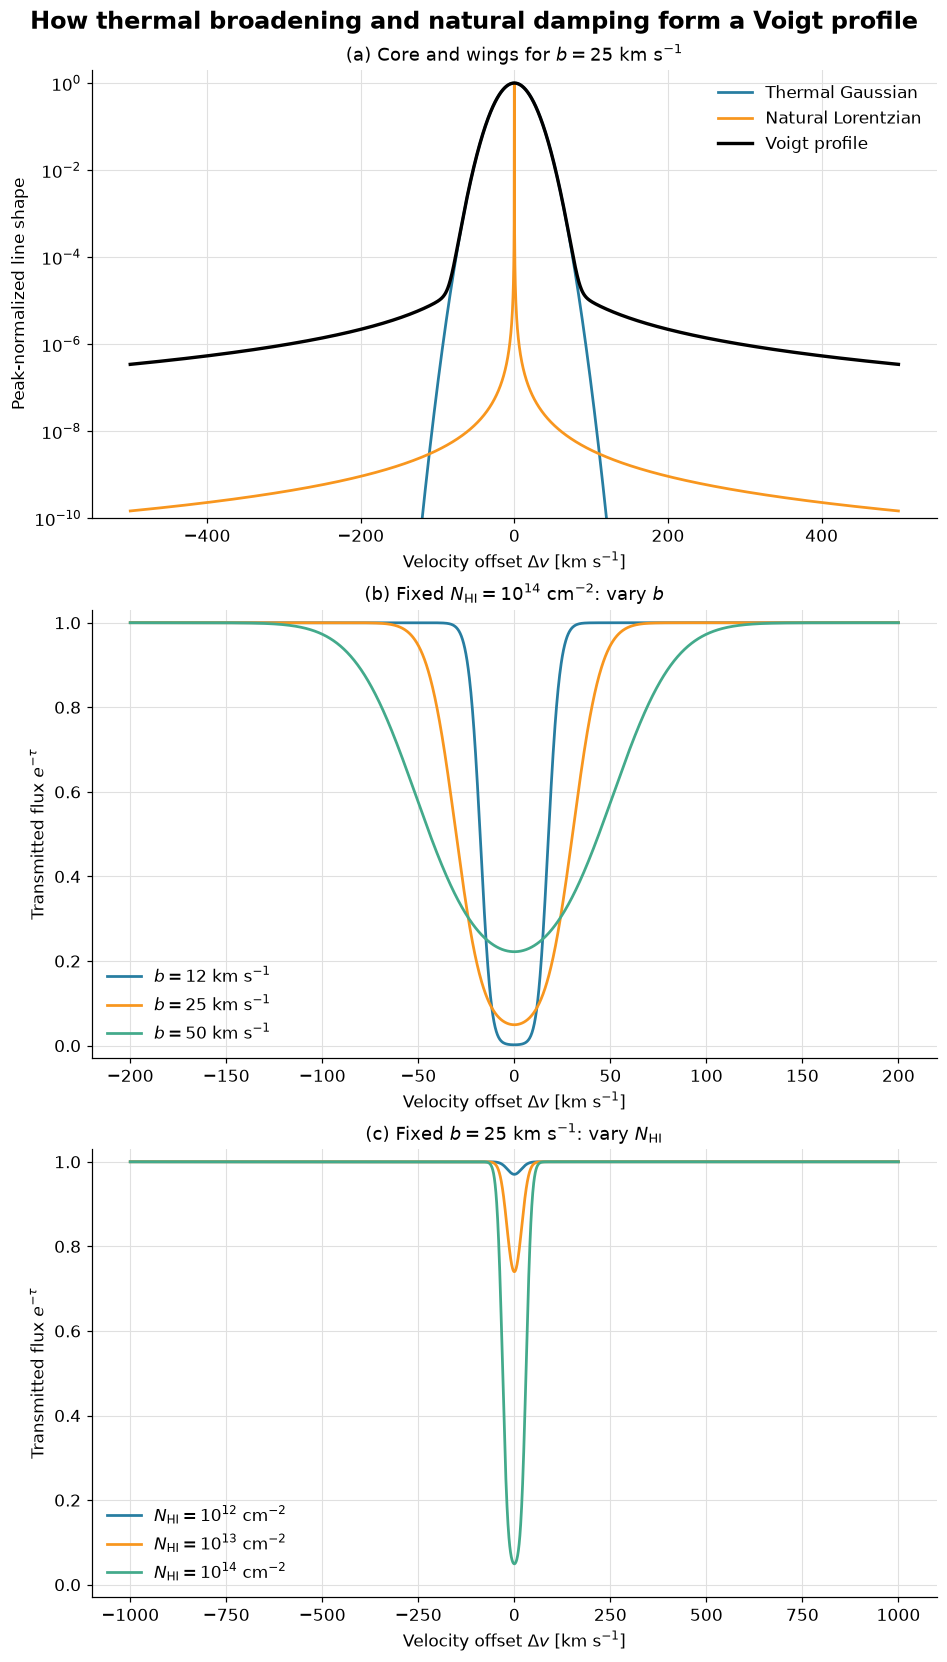

In [243]:
fig, axes = plt.subplots(3, 1, figsize=(8.5, 15), constrained_layout=True)

# (a) Gaussian, Lorentzian, and Voigt line shapes.
velocity_shape = np.linspace(-500.0, 500.0, 4001)
b_shape = 25.0
b_shape_cms = b_shape * 1e5
a_shape = gamma_alpha * c_cms / (4.0 * np.pi * nu_alpha * b_shape_cms)
u_shape = velocity_shape / b_shape
gaussian = np.exp(-u_shape**2)
lorentzian = a_shape**2 / (u_shape**2 + a_shape**2)
voigt = np.real(special.wofz(u_shape + 1j * a_shape))
voigt /= voigt.max()

ax = axes[0]
ax.semilogy(velocity_shape, gaussian, color="#277DA1", label="Thermal Gaussian")
ax.semilogy(velocity_shape, lorentzian, color="#F8961E", label="Natural Lorentzian")
ax.semilogy(velocity_shape, voigt, color="black", linewidth=2.2, label="Voigt profile")
ax.set(
    ylim=(1e-10, 2.0),
    xlabel=r"Velocity offset $\Delta v$ [km s$^{-1}$]",
    ylabel="Peak-normalized line shape",
    title=rf"(a) Core and wings for $b={b_shape:.0f}$ km s$^{{-1}}$",
)
ax.legend(loc="upper right")

# (b) Hold column density fixed and vary thermal width.
velocity_core = np.linspace(-200.0, 200.0, 2001)
fixed_N_HI = 1e14
ax = axes[1]
for colour, b_value in zip(["#277DA1", "#F8961E", "#43AA8B"], [12.0, 25.0, 50.0]):
    cloud_tau = single_cloud_tau(velocity_core, fixed_N_HI, b_value)
    ax.plot(
        velocity_core,
        np.exp(-cloud_tau),
        color=colour,
        label=rf"$b={b_value:.0f}$ km s$^{{-1}}$",
    )
ax.set(
    ylim=(-0.03, 1.03),
    xlabel=r"Velocity offset $\Delta v$ [km s$^{-1}$]",
    ylabel=r"Transmitted flux $e^{-\tau}$",
    title=r"(b) Fixed $N_{\rm HI}=10^{14}\ \mathrm{cm}^{-2}$: vary $b$",
)
ax.legend(loc="lower left")

# (c) Hold thermal width fixed and vary column density.
velocity_wings = np.linspace(-1000.0, 1000.0, 4001)
fixed_b = 25.0
ax = axes[2]
for colour, N_HI_value in zip(["#277DA1", "#F8961E", "#43AA8B"], [1e12, 1e13, 1e14]):
    exponent = int(np.log10(N_HI_value))
    cloud_tau = single_cloud_tau(velocity_wings, N_HI_value, fixed_b)
    ax.plot(
        velocity_wings,
        np.exp(-cloud_tau),
        color=colour,
        label=rf"$N_{{\rm HI}}=10^{{{exponent}}}\ \mathrm{{cm}}^{{-2}}$",
    )
ax.set(
    ylim=(-0.03, 1.03),
    xlabel=r"Velocity offset $\Delta v$ [km s$^{-1}$]",
    ylabel=r"Transmitted flux $e^{-\tau}$",
    title=rf"(c) Fixed $b={fixed_b:.0f}$ km s$^{{-1}}$: vary $N_{{\rm HI}}$",
)
ax.legend(loc="lower left")

for ax in axes.flat:
    finish_axis(ax)

fig.suptitle(
    "How thermal broadening and natural damping form a Voigt profile",
    fontsize=16,
    fontweight="semibold",
)
voigt_figure_directory = Path("figures")
voigt_figure_directory.mkdir(exist_ok=True)
fig.savefig(
    voigt_figure_directory / "Voigt_profile_mock_absorbers.png",
    bbox_inches="tight",
    facecolor="white",
)
plt.show()


> **Read the figure from left to right:** $N_{\rm HI}$ controls the total amount of absorption; $b$ controls the thermal width of the line core; natural broadening produces extended wings that become conspicuous only at very high column density. The continuous CAMELS calculation applies the same local profile physics to every skewer cell.


## 2.4 Select a box and define a sightline

The sightline runs along the first spatial array axis, which we call $x$. Fixing one $y$ index and one $z$ index selects a straight, axis-aligned skewer. Change the three integers below to synthesize a spectrum from another sightline.

In [230]:
data_directory = Path("Sims/CMD_z=2_grid128")
output_directory = Path("figures")
output_directory.mkdir(exist_ok=True)

# -------------------------- student configuration -------------------------
seed = 0
y_index = 64
z_index = 64

box_size = 25.0       # comoving Mpc/h
box_redshift = 2.0
# --------------------------------------------------------------------------


## 2.5 Open the two fields required for the skewer

Each file has shape $(27,128,128,128)$: simulation number followed by the three spatial axes. The same array index in different field files refers to the same voxel in the same simulated universe. Read-only memory mapping avoids copying every simulation into memory.

In [231]:
HI_boxes = np.load(
    data_directory / "Grids_HI_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)
T_boxes = np.load(
    data_directory / "Grids_T_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)

if HI_boxes.shape != T_boxes.shape:
    raise ValueError(
        f"HI and temperature grids must match, but found "
        f"{HI_boxes.shape} and {T_boxes.shape}."
    )
if HI_boxes.ndim != 4:
    raise ValueError(
        "Expected arrays with shape (simulation, x, y, z); "
        f"received {HI_boxes.shape}."
    )

number_of_simulations, nx, ny, nz = HI_boxes.shape
if not (0 <= seed < number_of_simulations):
    raise IndexError(f"seed must lie between 0 and {number_of_simulations - 1}.")
if not (0 <= y_index < ny and 0 <= z_index < nz):
    raise IndexError(
        f"y_index and z_index must lie within 0…{ny - 1} and 0…{nz - 1}."
    )

print(f"HI grid shape          : {HI_boxes.shape}")
print(f"Temperature grid shape : {T_boxes.shape}")
print(f"Selected skewer        : seed={seed}, y={y_index}, z={z_index}")


HI grid shape          : (27, 128, 128, 128)
Temperature grid shape : (27, 128, 128, 128)
Selected skewer        : seed=0, y=64, z=64


## 2.6 Visualize the skewer within the simulation volume

The left panel is a geometric representation of the periodic simulation cube. The red line is the selected skewer. The right panel projects the neutral-hydrogen field along $x$ and marks the point where the skewer passes through the transverse $(y,z)$ plane.

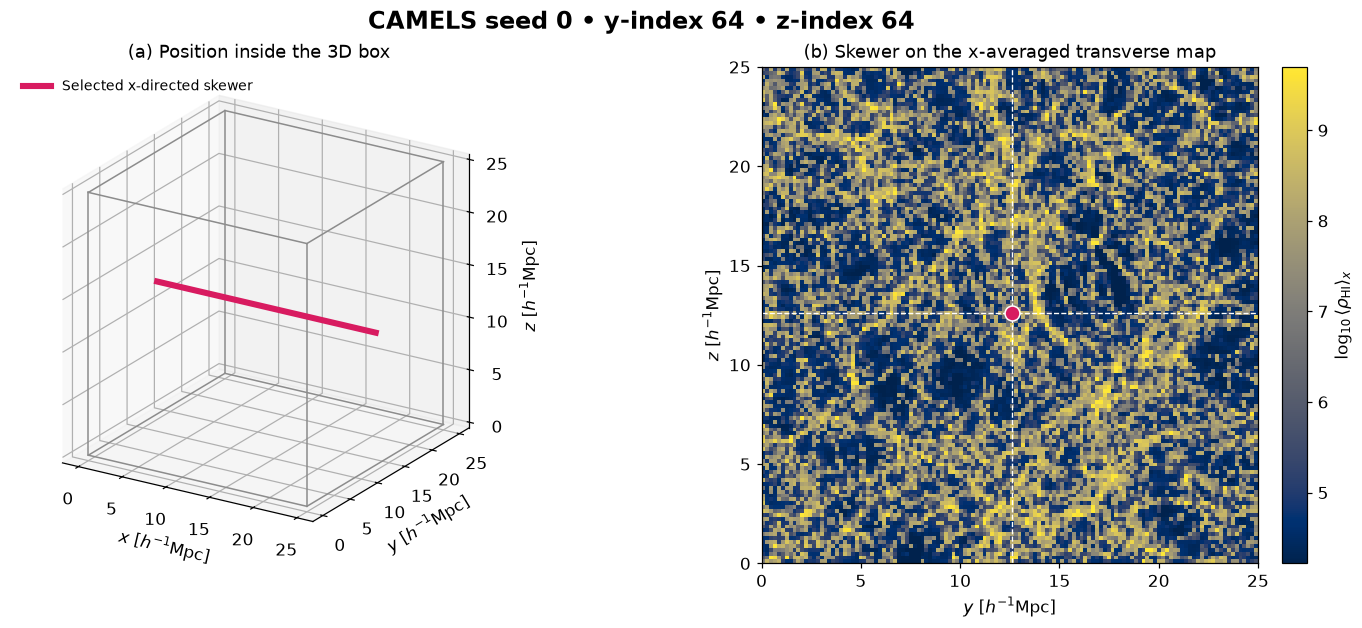

In [232]:
number_of_cells = HI_boxes.shape[1]
cell_size = box_size / number_of_cells
y_coordinate = (y_index + 0.5) * cell_size
z_coordinate = (z_index + 0.5) * cell_size

fig = plt.figure(figsize=(13, 5.6), constrained_layout=True)

# Left: geometric location of the skewer in the periodic cube.
ax_3d = fig.add_subplot(1, 2, 1, projection="3d")
cube_edges = [
    ((0, 0, 0), (box_size, 0, 0)),
    ((0, box_size, 0), (box_size, box_size, 0)),
    ((0, 0, box_size), (box_size, 0, box_size)),
    ((0, box_size, box_size), (box_size, box_size, box_size)),
    ((0, 0, 0), (0, box_size, 0)),
    ((box_size, 0, 0), (box_size, box_size, 0)),
    ((0, 0, box_size), (0, box_size, box_size)),
    ((box_size, 0, box_size), (box_size, box_size, box_size)),
    ((0, 0, 0), (0, 0, box_size)),
    ((box_size, 0, 0), (box_size, 0, box_size)),
    ((0, box_size, 0), (0, box_size, box_size)),
    ((box_size, box_size, 0), (box_size, box_size, box_size)),
]
for start, end in cube_edges:
    ax_3d.plot(*zip(start, end), color="0.55", linewidth=1)

ax_3d.plot(
    [0, box_size],
    [y_coordinate, y_coordinate],
    [z_coordinate, z_coordinate],
    color=COLORS["highlight"],
    linewidth=4,
    label="Selected x-directed skewer",
)
ax_3d.set(
    xlabel=r"$x\ [h^{-1}\mathrm{Mpc}]$",
    ylabel=r"$y\ [h^{-1}\mathrm{Mpc}]$",
    zlabel=r"$z\ [h^{-1}\mathrm{Mpc}]$",
    title="(a) Position inside the 3D box",
)
ax_3d.set_box_aspect((1, 1, 1))
ax_3d.set_proj_type("ortho")
ax_3d.view_init(elev=22, azim=-58)
ax_3d.legend(loc="upper left", fontsize=9)

# Right: mean along x, leaving the transverse (y, z) plane.
ax_map = fig.add_subplot(1, 2, 2)
HI_projection = safe_log10(HI_boxes[seed].mean(axis=0)).T
colour_min, colour_max = robust_limits([HI_projection])
image = ax_map.imshow(
    HI_projection,
    origin="lower",
    extent=[0, box_size, 0, box_size],
    cmap="cividis",
    vmin=colour_min,
    vmax=colour_max,
    interpolation="nearest",
)
ax_map.axvline(y_coordinate, color="white", linestyle="--", linewidth=0.9)
ax_map.axhline(z_coordinate, color="white", linestyle="--", linewidth=0.9)
ax_map.scatter(
    y_coordinate,
    z_coordinate,
    s=95,
    color=COLORS["highlight"],
    edgecolor="white",
    linewidth=1,
    zorder=3,
)
ax_map.set(
    xlabel=r"$y\ [h^{-1}\mathrm{Mpc}]$",
    ylabel=r"$z\ [h^{-1}\mathrm{Mpc}]$",
    title="(b) Skewer on the x-averaged transverse map",
    aspect="equal",
)
colourbar = fig.colorbar(image, ax=ax_map, pad=0.02)
colourbar.set_label(r"$\log_{10}\langle\rho_{\rm HI}\rangle_x$")

fig.suptitle(
    f"CAMELS seed {seed} • y-index {y_index} • z-index {z_index}",
    fontsize=16,
    fontweight="semibold",
)
fig.savefig(
    output_directory / f"CAMELS_skewer_geometry_seed_{seed}.png",
    bbox_inches="tight",
    facecolor="white",
)
plt.show()


> **Geometry check:** the point in panel (b) is not one absorbing cell. It labels the fixed transverse coordinates $(y,z)$ of the complete red line in panel (a). Moving along that line changes only the $x$ index.


## 2.7 Extract the one-dimensional physical fields

Cell centres are used as absorber positions,

$$x_i=\left(i+\frac{1}{2}\right)\Delta x, \qquad \Delta x=\frac{L}{N}.$$

Here $\Delta x=25/128\simeq0.195\ h^{-1}{\rm Mpc}$. Direct indexing extracts the corresponding HI density and temperature values. The CMD velocity field is deliberately not loaded because it does not provide the signed line-of-sight component needed for the absorption calculation.

In [233]:
x_abs = (np.arange(number_of_cells) + 0.5) * cell_size

HI_grid_density = HI_boxes[seed, :, y_index, z_index].copy()
temperature = T_boxes[seed, :, y_index, z_index].copy()

print(f"Number of absorber cells : {number_of_cells}")
print(f"Comoving cell width      : {cell_size:.4f} Mpc/h")
print(
    "Temperature range       : "
    f"{temperature.min():.3g}–{temperature.max():.3g} K"
)


Number of absorber cells : 128
Comoving cell width      : 0.1953 Mpc/h
Temperature range       : 4.88e+03–1.38e+05 K


## 2.8 Convert comoving position to absorber redshift

The box is treated as a short comoving segment centred on $z_{\rm box}=2$. For a small interval, the comoving radial-distance relation $d\chi=c\,dz/H(z)$ gives

$$z_i\simeq z_{\rm box}+\frac{H(z_{\rm box})}{c}\,\frac{x_i-L/2}{h}.$$

The factor $1/h$ converts Mpc/$h$ to Mpc. This linear approximation is adequate across one 25 Mpc/$h$ box; it spans only about $\Delta z=0.025$. Following the supplied routine, this notebook adopts Planck18. Its $h=0.6766$ differs slightly from the fixed CMD value near 0.67; precision work should use the exact simulation-header cosmology.

In [234]:
distance_from_box_centre_Mpc = (x_abs - box_size / 2.0) / cosmo.h
H_z = cosmo.H(box_redshift).to_value(u.km / u.s / u.Mpc)
c_kms = c.to_value(u.km / u.s)

z_abs = box_redshift + H_z * distance_from_box_centre_Mpc / c_kms
z_eval = z_abs.copy()

print(f"Planck18 h              : {cosmo.h:.4f}")
print(f"H(z={box_redshift:.1f})               : {H_z:.2f} km s^-1 Mpc^-1")
print(f"Absorber-redshift range : {z_abs.min():.5f}–{z_abs.max():.5f}")


Planck18 h              : 0.6766
H(z=2.0)               : 204.04 km s^-1 Mpc^-1
Absorber-redshift range : 1.98752–2.01248


## 2.9 Convert HI mass density to physical number density

The grid stores neutral-hydrogen mass density in

$$\frac{M_\odot/h}{({\rm Mpc}/h)^3}.$$

Because the CAMELS box coordinates and voxel volume are comoving, the physical density at absorber redshift $z_i$ is

$$\rho_{{\rm HI,phys},i}=(1+z_i)^3\rho_{{\rm HI,com},i}.$$

Finally,

$$n_{{\rm HI},i}=\frac{\rho_{{\rm HI,phys},i}}{m_{\rm H}}, \qquad m_{\rm H}\simeq m_p+m_e.$$

Astropy performs the solar-mass/Mpc to g/cm conversion explicitly below. Temperature is already stored in kelvin and needs no unit rescaling. The CMD temperature is mass-weighted within each voxel, another approximation when it is assigned to all neutral hydrogen in that voxel.

In [235]:
CMD_density_unit = (u.Msun / cosmo.h) / (u.Mpc / cosmo.h) ** 3

rho_HI_comoving = (HI_grid_density * CMD_density_unit).to_value(u.g / u.cm**3)
rho_HI_physical = rho_HI_comoving * (1.0 + z_abs) ** 3
hydrogen_mass = (m_p + m_e).to_value(u.g)
n_HI = rho_HI_physical / hydrogen_mass

# CMD provides a speed modulus, not a signed line-of-sight component.
v_pec = np.zeros_like(n_HI)

print(
    "Physical neutral-hydrogen number density: "
    f"{n_HI.min():.3e}–{n_HI.max():.3e} cm^-3"
)


Physical neutral-hydrogen number density: 4.322e-13–3.398e-09 cm^-3


## 2.10 Formulate the Lyα optical depth

For absorber cell $i$, the thermal Doppler parameter is

$$b_i=\sqrt{\frac{2k_{\rm B}T_i}{m_{\rm H}}}.$$

Natural and thermal broadening are combined through the Voigt function

$$H(a_i,u_{ij})=\operatorname{Re}\left[w(u_{ij}+ia_i)\right],$$

where $w$ is the Faddeeva function and

$$a_i=\frac{\Gamma_{\alpha}c}{4\pi\nu_{\alpha}b_i},$$

$$u_{ij}=\frac{c(z_i-z_j)}{b_i(1+z_j)}+\frac{v_{\parallel,i}}{b_i}.$$

The discretized optical depth evaluated at redshift $z_j$ is

$$\tau(z_j)=\sum_i\frac{c\,I_{\alpha}}{\sqrt{\pi}}\frac{\Delta x_{\rm com}\,n_{{\rm HI},i}}{b_i(1+z_i)}H(a_i,u_{ij}).$$

The factor $(1+z_i)^{-1}$ converts the comoving path element to a proper path element. The constants $I_{\alpha}=4.45\times10^{-18}$, $\lambda_{\alpha}=1215.67$ Å, and $\Gamma_{\alpha}=6.262\times10^8\ {\rm s}^{-1}$ are those used by the supplied implementation.

In [236]:
def tau(x_abs, z_abs, z_eval, n_HI, T, v_pec):
    '''Compute Lyα optical depth for one or more skewers.

    Parameters
    ----------
    x_abs : (n_cells,) array
        Comoving absorber positions in Mpc/h.
    z_abs, z_eval : (n_cells,) arrays
        Absorber redshifts and redshifts where tau is evaluated.
    n_HI, T, v_pec : (n_skewers, n_cells) arrays
        Physical HI number density [cm^-3], temperature [K], and signed
        line-of-sight peculiar velocity [km/s].

    Returns
    -------
    optical_depth : (n_skewers, n_eval) array
    '''
    if n_HI.ndim != 2:
        raise ValueError("n_HI, T, and v_pec must include a leading skewer axis.")
    if not (n_HI.shape == T.shape == v_pec.shape):
        raise ValueError("n_HI, T, and v_pec must have identical shapes.")

    # Convert positions and thermal velocities to cgs units.
    x_abs_cm = u.Mpc.to(u.cm) * x_abs / cosmo.h
    hydrogen_mass_g = (m_p + m_e).to_value(u.g)
    thermal_b_cms = np.sqrt(
        2.0 * k_B.to_value(u.erg / u.K) * T / hydrogen_mass_g
    )
    cell_width_cm = np.mean(np.diff(x_abs_cm))

    # The prefactor contains the absorber properties for every skewer cell.
    cell_prefactor = (
        c_cms
        * I_alpha
        / np.sqrt(np.pi)
        * cell_width_cm
        * n_HI
        / (thermal_b_cms * (1.0 + z_abs[None, :]))
    )

    # Add singleton axes to construct every absorber–evaluation pair.
    absorber_redshift = z_abs[None, :, None]
    evaluation_redshift = z_eval[None, None, :]
    thermal_b = thermal_b_cms[:, :, None]
    peculiar_velocity = v_pec[:, :, None] * 1e5

    damping_parameter = gamma_alpha * c_cms / (
        4.0 * np.pi * nu_alpha * thermal_b
    )
    dimensionless_offset = (
        c_cms
        * (absorber_redshift - evaluation_redshift)
        / (thermal_b * (1.0 + evaluation_redshift))
        + peculiar_velocity / thermal_b
    )
    voigt_kernel = np.real(
        special.wofz(dimensionless_offset + 1j * damping_parameter)
    )

    contribution = cell_prefactor[:, :, None] * voigt_kernel
    return contribution.sum(axis=1)


## 2.11 Generate the Lyα forest

The routine accepts a leading sightline axis, so the one-dimensional fields are temporarily given shape (1, 128). The continuum-normalized transmitted flux is

$$F(z)=\exp[-\tau(z)].$$

In [237]:
optical_depth = tau(
    x_abs=x_abs,
    z_abs=z_abs,
    z_eval=z_eval,
    n_HI=n_HI[None, :],
    T=temperature[None, :],
    v_pec=v_pec[None, :],
)[0]

transmitted_flux = np.exp(-optical_depth)
mean_flux = transmitted_flux.mean()
effective_optical_depth = -np.log(mean_flux)

print(f"Optical-depth range           : {optical_depth.min():.3g}–{optical_depth.max():.3g}")
print(f"Mean transmitted flux         : {mean_flux:.4f}  (not rescaled)")
print(f"Effective optical depth -ln<F>: {effective_optical_depth:.4f}")


Optical-depth range           : 0.011–31.2
Mean transmitted flux         : 0.6957  (not rescaled)
Effective optical depth -ln<F>: 0.3629


## 2.12 Plot the input fields and the resulting Lyα forest

All panels share the same comoving coordinate, so density and temperature structures can be compared directly with absorption features. The calculation adopts $v_\parallel=0$ because CMD does not provide a signed line-of-sight velocity component.

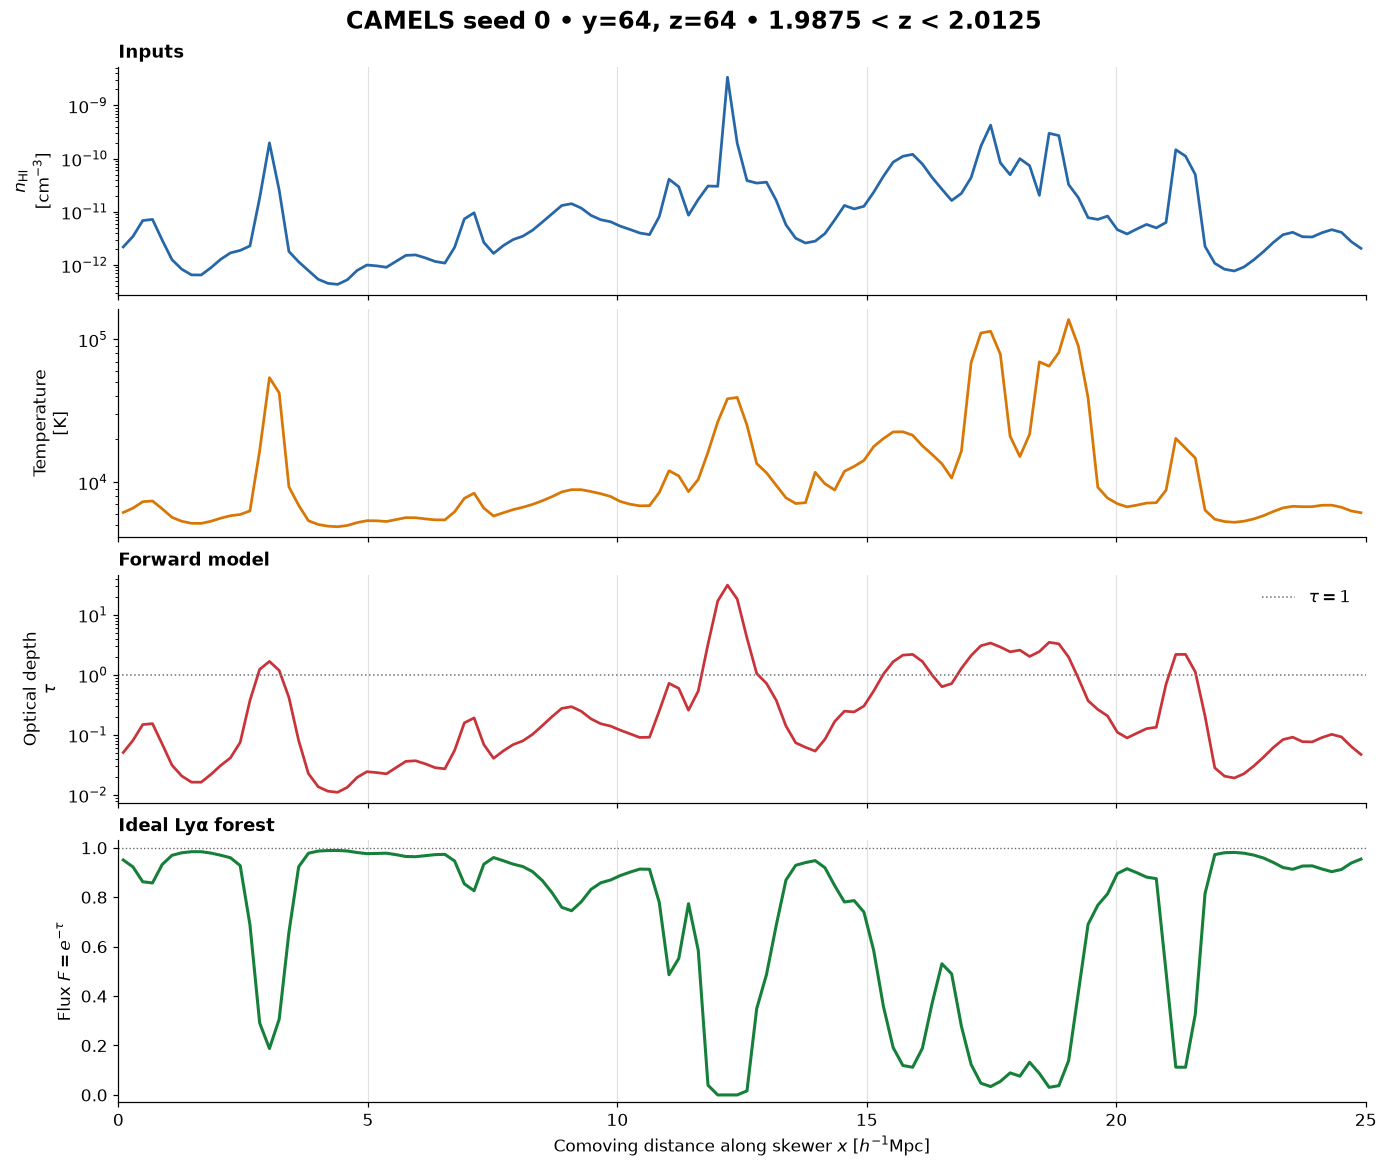

In [244]:
fig, axes = plt.subplots(
    4,
    1,
    figsize=(12.5, 10.5),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 1, 1, 1.15]},
)

axes[0].semilogy(x_abs, n_HI, color=COLORS["density"])
axes[0].set_ylabel(r"$n_{\rm HI}$" + "\n" + r"[cm$^{-3}$]")
axes[0].set_title("Inputs", loc="left", fontweight="semibold")

axes[1].semilogy(x_abs, temperature, color=COLORS["temperature"])
axes[1].set_ylabel("Temperature\n[K]")

axes[2].semilogy(x_abs, optical_depth, color=COLORS["optical_depth"])
axes[2].axhline(1.0, color="0.45", linestyle=":", linewidth=1, label=r"$\tau=1$")
axes[2].set_ylabel("Optical depth\n" + r"$\tau$")
axes[2].set_title("Forward model", loc="left", fontweight="semibold")
axes[2].legend(loc="upper right")

axes[3].plot(x_abs, transmitted_flux, color=COLORS["flux"], linewidth=2)
axes[3].axhline(1.0, color="0.4", linestyle=":", linewidth=0.9)
axes[3].set(
    ylabel=r"Flux $F=e^{-\tau}$",
    xlabel=r"Comoving distance along skewer $x\ [h^{-1}\mathrm{Mpc}]$",
    ylim=(-0.03, 1.03),
)
axes[3].set_title("Ideal Lyα forest", loc="left", fontweight="semibold")

for ax in axes:
    finish_axis(ax, grid_axis="x")
    ax.set_xlim(0, box_size)

fig.suptitle(
    f"CAMELS seed {seed} • y={y_index}, z={z_index} • "
    f"{z_abs.min():.4f} < z < {z_abs.max():.4f}",
    fontsize=16,
    fontweight="semibold",
)
fig.savefig(
    output_directory / f"CAMELS_Lya_forest_seed_{seed}.png",
    bbox_inches="tight",
    facecolor="white",
)
plt.show()


> **Trace one feature vertically:** a peak in $n_{\rm HI}$ usually raises $\tau$ and creates a flux trough, but the correspondence is not one-to-one. Thermal broadening spreads the contribution of one absorber cell over neighbouring evaluation pixels. Once $F\simeq0$, very different large optical depths become visually indistinguishable. This is the saturation problem encountered in inversion.


## 2.13 Interpretation and limitations

- Larger $n_{\rm HI}$ generally produces larger optical depth and lower transmitted flux.
- Temperature controls the Doppler width: hotter cells distribute their absorption over a broader velocity interval.
- The peculiar-velocity term is zero here because a signed velocity component is unavailable.
- Each voxel is about $0.195\ h^{-1}{\rm Mpc}$ wide. Sub-voxel gas structure is therefore absent, and the mass-weighted voxel temperature is only an approximate temperature for the neutral absorber.
- One snapshot is used across the short redshift interval (the snapshot approximation).
- The flux in the preceding figure is the ideal, noiseless model before an instrumental line-spread function is applied. The next section adds these observational effects.

To make another skewer, change seed, y_index, or z_index near the beginning and rerun the notebook.

## 2.14 From an ideal forest to mock observed spectra

A real spectrograph does not record the ideal transmitted flux directly. Two particularly important observational effects are:

1. **Finite instrumental resolution.** We approximate the line-spread function (LSF) by a Gaussian. A spectrograph with resolving power $R=\lambda/\Delta\lambda$ has a velocity full width at half maximum

   $$\mathrm{FWHM}_v \simeq \frac{c}{R}, \qquad \sigma_v=\frac{\mathrm{FWHM}_v}{2\sqrt{2\ln 2}}.$$

   Convolution with this LSF blends neighbouring absorption and removes narrow structure. It must be applied to the **flux**, not to the optical depth.

2. **Pixel noise.** For a continuum-normalized spectrum with signal-to-noise ratio $\mathrm{S/N}$ per pixel, we use independent Gaussian noise with standard deviation $\sigma_F=1/(\mathrm{S/N})$. Real data can additionally contain wavelength-dependent noise, correlated detector noise, sky residuals, and continuum-fitting errors; those complications are omitted here.

The instrumental examples below use the native 128-pixel sightline. No interpolation is performed. We therefore restrict the resolving powers to line-spread functions sampled by at least about two native pixels.

### 2.14.1 Instrumental resolution

The native sightline has a velocity spacing of about $20\ {\rm km\,s^{-1}}$. We compare two illustrative cases: medium resolution with a FWHM of about $50\ {\rm km\,s^{-1}}$, and low resolution with a FWHM of about $150\ {\rm km\,s^{-1}}$. The labels are relative to this mock dataset, rather than a general classification of astronomical spectrographs.

In [239]:
velocity_native = c_kms * (z_eval - box_redshift) / (1.0 + box_redshift)
ideal_flux_native = transmitted_flux.copy()


def apply_gaussian_lsf(flux, velocity, resolving_power):
    '''Convolve continuum-normalized flux with a Gaussian instrumental LSF.'''
    if resolving_power <= 0:
        raise ValueError("resolving_power must be positive.")

    pixel_width_kms = np.mean(np.diff(velocity))
    if pixel_width_kms <= 0:
        raise ValueError("velocity must increase monotonically.")

    fwhm_kms = c_kms / resolving_power
    sigma_kms = fwhm_kms / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    sigma_pixels = sigma_kms / pixel_width_kms
    return ndimage.gaussian_filter1d(
        flux,
        sigma=sigma_pixels,
        mode="nearest",
    )


resolutions = {
    "Medium resolution": 6_000,
    "Low resolution": 2_000,
}
resolution_fluxes = {
    label: apply_gaussian_lsf(ideal_flux_native, velocity_native, R)
    for label, R in resolutions.items()
}

native_pixel_width = np.mean(np.diff(velocity_native))
print(f"Native velocity spacing: {native_pixel_width:.2f} km/s")
for label, R in resolutions.items():
    fwhm_kms = c_kms / R
    print(
        f"{label:18s}: R={R:6,d}, FWHM={fwhm_kms:6.1f} km/s "
        f"({fwhm_kms / native_pixel_width:.2f} native pixels)"
    )


Native velocity spacing: 19.63 km/s
Medium resolution : R= 6,000, FWHM=  50.0 km/s (2.54 native pixels)
Low resolution    : R= 2,000, FWHM= 149.9 km/s (7.63 native pixels)


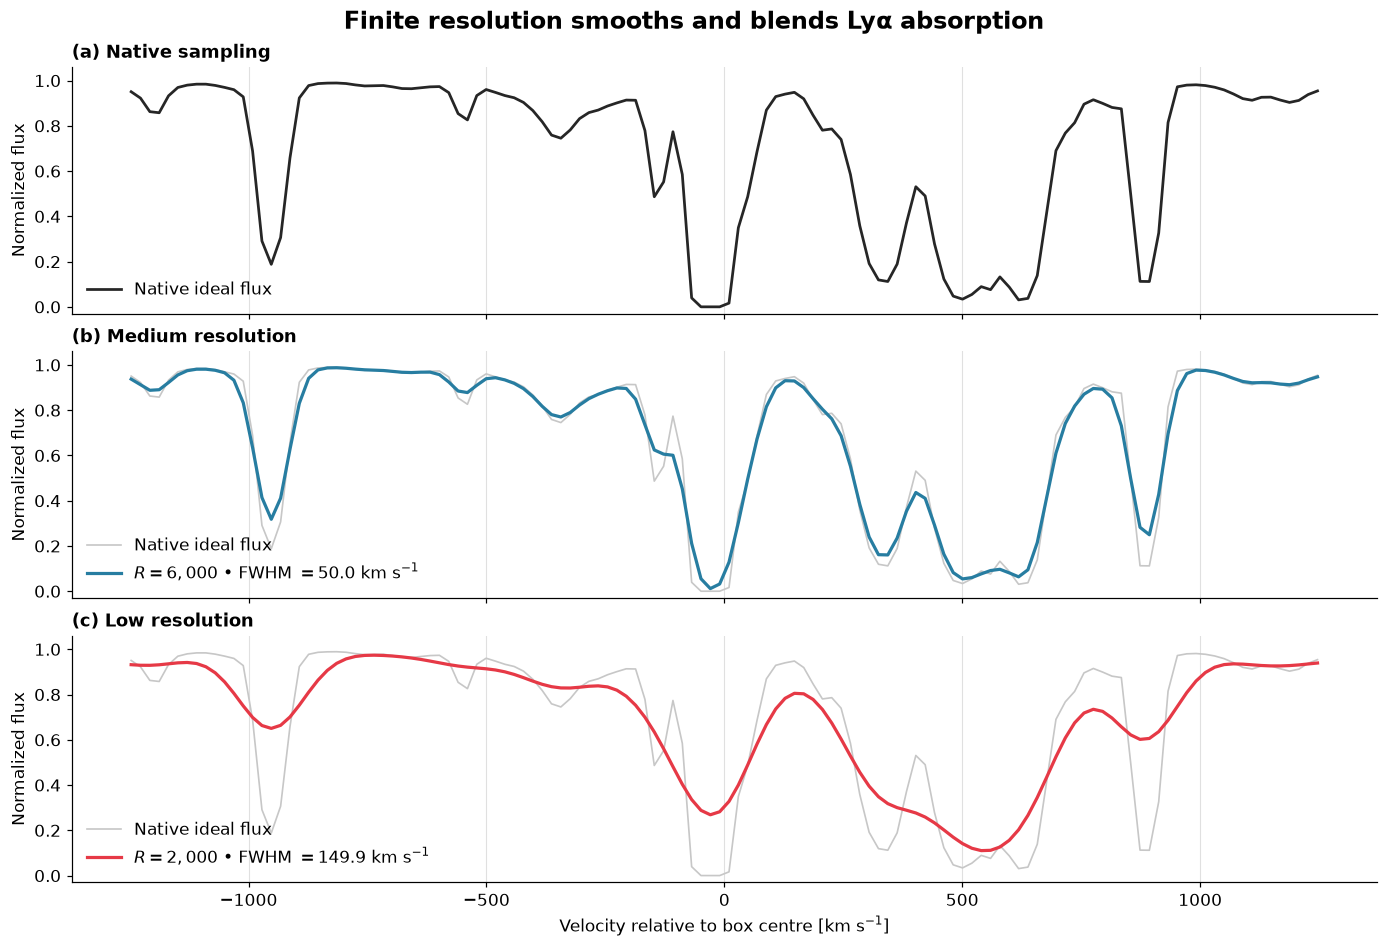

In [248]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12.5, 8.5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

# Top panel: the native ideal spectrum provides an uncluttered reference.
axes[0].plot(
    velocity_native,
    ideal_flux_native,
    color="0.15",
    label="Native ideal flux",
)
axes[0].set_title("(a) Native sampling", loc="left", fontweight="semibold")
axes[0].legend(loc=3)

resolution_colours = ["#277DA1", "#E63946"]
for panel_number, (ax, (label, R), colour) in enumerate(
    zip(axes[1:], resolutions.items(), resolution_colours),
    start=2,
):
    smoothed_flux = resolution_fluxes[label]
    ax.plot(
        velocity_native,
        ideal_flux_native,
        color="0.78",
        linewidth=1.1,
        label="Native ideal flux",
    )
    ax.plot(
        velocity_native,
        smoothed_flux,
        color=colour,
        linewidth=2.1,
        label=rf"$R={R:,}$ • FWHM $={c_kms / R:.1f}$ km s$^{{-1}}$",
    )
    ax.set_title(
        f"({chr(96 + panel_number)}) {label}",
        loc="left",
        fontweight="semibold",
    )
    ax.legend(loc=3)

for ax in axes:
    ax.set_ylabel("Normalized flux")
    ax.set_ylim(-0.03, 1.06)
    finish_axis(ax, grid_axis="x")

axes[-1].set_xlabel(r"Velocity relative to box centre [km s$^{-1}$]")
fig.suptitle(
    "Finite resolution smooths and blends Lyα absorption",
    fontsize=16,
    fontweight="semibold",
)
fig.savefig(
    output_directory / f"CAMELS_Lya_instrument_resolution_seed_{seed}.png",
    bbox_inches="tight",
    facecolor="white",
)
plt.show()


**What to notice:**

- At medium resolution, most broad troughs survive and narrow minima become slightly shallower.
- At low resolution, neighbouring troughs merge and sharp structures disappear.
- Convolution conserves neither the depth nor the apparent position of every individual minimum; it redistributes absorption over neighbouring pixels.
- The top reference panel is intentionally separate, making the information loss easier to compare without overplotting three strong curves.


### 2.14.2 Signal-to-noise ratio

To isolate the effect of noise, we now keep the medium resolving power fixed at $R=6{,}000$ and generate reproducible realizations with $\mathrm{S/N}=100$, 30, and 10 per native pixel. Noise is added after convolution. We deliberately do not clip values outside $0\leq F\leq1$: such values are normal noise fluctuations in a continuum-normalized observed spectrum.

In [249]:
noise_resolving_power = 6_000
medium_flux_native = resolution_fluxes["Medium resolution"]

signal_to_noise_values = [50, 20, 5]
noise_rng = np.random.default_rng(314159)
noisy_fluxes = {
    snr: medium_flux_native + noise_rng.normal(0.0, 1.0 / snr, medium_flux_native.size)
    for snr in signal_to_noise_values
}

print(f"Resolving power held fixed at R = {noise_resolving_power:,}")
print(f"Native pixel width: {np.mean(np.diff(velocity_native)):.1f} km/s")

Resolving power held fixed at R = 6,000
Native pixel width: 19.6 km/s


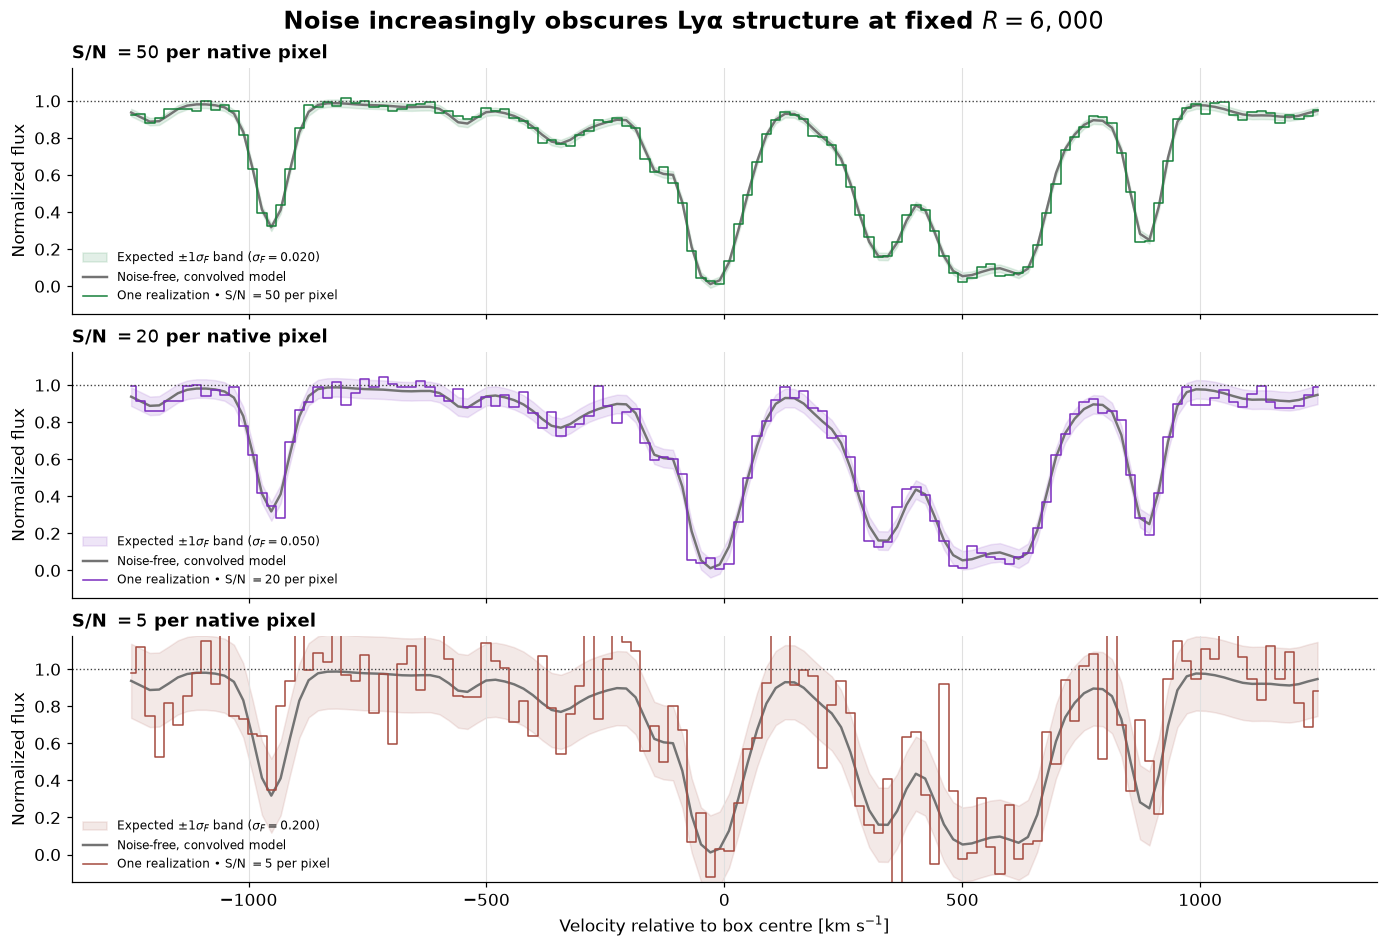

In [251]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12.5, 8.5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
noise_colours = ["#16803A", "#7B2CBF", "#A44A3F"]

for ax, snr, colour in zip(axes, signal_to_noise_values, noise_colours):
    one_sigma = 1.0 / snr
    ax.fill_between(
        velocity_native,
        medium_flux_native - one_sigma,
        medium_flux_native + one_sigma,
        color=colour,
        alpha=0.12,
        label=rf"Expected $\pm1\sigma_F$ band ($\sigma_F={one_sigma:.3f}$)",
    )
    ax.plot(
        velocity_native,
        medium_flux_native,
        color="0.45",
        linewidth=1.6,
        label="Noise-free, convolved model",
    )
    ax.step(
        velocity_native,
        noisy_fluxes[snr],
        where="mid",
        color=colour,
        linewidth=1.0,
        label=rf"One realization • S/N $={snr}$ per pixel",
    )
    ax.axhline(1.0, color="0.25", linestyle=":", linewidth=0.9)
    ax.set_ylabel("Normalized flux")
    ax.set_ylim(-0.15, 1.18)
    ax.set_title(rf"S/N $={snr}$ per native pixel", loc="left", fontweight="semibold")
    ax.legend(loc=3, fontsize=8)
    finish_axis(ax, grid_axis="x")

axes[-1].set_xlabel(r"Velocity relative to box centre [km s$^{-1}$]")
fig.suptitle(
    rf"Noise increasingly obscures Lyα structure at fixed $R={noise_resolving_power:,}$",
    fontsize=16,
    fontweight="semibold",
)
fig.savefig(
    output_directory / f"CAMELS_Lya_SNR_seed_{seed}.png",
    bbox_inches="tight",
    facecolor="white",
)
plt.show()


At high S/N, the noisy spectrum follows the convolved model closely. As S/N falls, shallow absorption becomes difficult to distinguish from noise, the apparent positions of minima fluctuate, and taking $\tau=-\ln F$ becomes unstable near non-positive flux. The shaded region is the expected $\pm1\sigma_F$ noise scale, while each stepped curve is one random realization. These are central reasons why Lyα inversion requires a noise model and regularization.


## Final take-away

The notebook has followed the complete chain

$$
\text{3D CAMELS fields}
\;\longrightarrow\;
\text{1D skewer}
\;\longrightarrow\;
\tau
\;\longrightarrow\;
F=e^{-\tau}
\;\longrightarrow\;
\text{finite-resolution, noisy spectrum}.
$$

Each arrow discards or mixes information. Reconstructing the underlying field therefore requires both a forward model and an explicit treatment of resolution, noise, saturation, and any missing peculiar-velocity information.
